# Cuaderno de experimentos de PageRank

## Implementacion propia, validacion con NetworkX y analisis empirico

En este cuaderno se construye PageRank desde cero, se valida la implementacion propia contra `NetworkX` y se analizan varios experimentos para estudiar precision, convergencia, sensibilidad y rendimiento.

### Objetivos
1. Representar un grafo dirigido en Python.
2. Construir la matriz de transicion de PageRank.
3. Manejar correctamente los nodos colgantes.
4. Implementar PageRank mediante iteracion de potencias.
5. Validar los resultados contra `NetworkX`.
6. Analizar el efecto del damping, la sensibilidad estructural y los tiempos de ejecucion.


In [11]:
%pip install numpy pandas matplotlib networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
import time
import random
from pathlib import Path
from typing import Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

RANDOM_SEED = 2026
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Environment ready.")

Environment ready.


## Representacion del grafo

Representaremos un grafo dirigido como un diccionario de Python en el que cada clave es un nodo y su valor es la lista de nodos a los que apunta.

```python
graph = {
    "A": ["B", "C"],
    "B": ["C"],
    "C": ["A"],
    "D": []
}
```


In [77]:

def normalize_graph(graph: Dict[str, List[str]]) -> Dict[str, List[str]]:
    """
    Ensure every referenced node appears as a key and remove duplicate outgoing edges
    while preserving order.
    """
    all_nodes = set(graph.keys())
    for targets in graph.values():
        all_nodes.update(targets)

    normalized = {}
    for node in sorted(all_nodes):
        outgoing = graph.get(node, [])
        seen = set()
        cleaned = []
        for target in outgoing:
            if target not in seen:
                seen.add(target)
                cleaned.append(target)
        normalized[node] = cleaned

    return normalized


def get_nodes(graph: Dict[str, List[str]]) -> List[str]:
    """
    Return all nodes in sorted order.
    """
    return sorted(normalize_graph(graph).keys())


def graph_to_digraph(graph: Dict[str, List[str]]) -> nx.DiGraph:
    """
    Convert adjacency-dict representation to a NetworkX DiGraph.
    """
    graph = normalize_graph(graph)
    G = nx.DiGraph()
    G.add_nodes_from(graph.keys())
    for source, targets in graph.items():
        for target in targets:
            G.add_edge(source, target)
    return G


def summarize_graph(graph: Dict[str, List[str]]) -> pd.DataFrame:
    """
    Return a summary table of node-level graph properties.
    """
    graph = normalize_graph(graph)
    nodes = get_nodes(graph)
    G = graph_to_digraph(graph)

    rows = []
    for node in nodes:
        rows.append({
            "node": node,
            "out_degree": len(graph[node]),
            "in_degree": G.in_degree(node),
            "is_dangling": len(graph[node]) == 0
        })

    return pd.DataFrame(rows).sort_values("node").reset_index(drop=True)


def total_edges(graph: Dict[str, List[str]]) -> int:
    graph = normalize_graph(graph)
    return sum(len(targets) for targets in graph.values())

In [78]:
manual_graph = {
    "A": ["B", "C"],
    "B": ["C"],
    "C": ["A"],
    "D": []
}

manual_graph = normalize_graph(manual_graph)

print("Nodes:", get_nodes(manual_graph))
print("Total edges:", total_edges(manual_graph))
summarize_graph(manual_graph)

Nodes: ['A', 'B', 'C', 'D']
Total edges: 4


,node,out_degree,in_degree,is_dangling
0,A,2,1,False
1,B,1,1,False
2,C,1,2,False
3,D,0,0,True


## Matriz de transicion para PageRank

Usamos la convencion columna-estocastica:

\[
M_{ij} =
egin{cases}

rac{1}{	ext{outdeg}(j)} & 	ext{si existe el enlace } j 	o i \
0 & 	ext{en otro caso}
\end{cases}
\]

En esta forma:
- cada columna representa el nodo que reparte probabilidad,
- cada fila representa el nodo que recibe probabilidad.

Si un nodo no tiene salidas, su columna se reemplaza por una distribucion uniforme sobre todos los nodos.


In [79]:
def build_transition_matrix(graph: Dict[str, List[str]]) -> Tuple[np.ndarray, List[str], Dict[str, int]]:
    """
    Build the PageRank transition matrix M using the column-stochastic convention.

    Returns:
        M: transition matrix
        nodes: sorted list of nodes
        index: mapping node -> integer index
    """
    graph = normalize_graph(graph)
    nodes = get_nodes(graph)
    n = len(nodes)
    index = {node: i for i, node in enumerate(nodes)}

    M = np.zeros((n, n), dtype=float)

    for source in nodes:
        j = index[source]
        outgoing = graph[source]

        if len(outgoing) == 0:
            # Dangling node: distribute uniformly to all nodes
            M[:, j] = 1.0 / n
        else:
            prob = 1.0 / len(outgoing)
            for target in outgoing:
                i = index[target]
                M[i, j] = prob

    return M, nodes, index


def transition_matrix_df(graph: Dict[str, List[str]]) -> pd.DataFrame:
    """
    Nicely formatted DataFrame for the transition matrix.
    Columns = source, rows = destination
    """
    M, nodes, _ = build_transition_matrix(graph)
    return pd.DataFrame(M, index=nodes, columns=nodes)

In [80]:
M_manual, nodes_manual, index_manual = build_transition_matrix(manual_graph)

print("Transition matrix M")
display(transition_matrix_df(manual_graph))

column_sums = M_manual.sum(axis=0)
print("Column sums (must all be 1):", column_sums)

Transition matrix M


,A,B,C,D
A,0.000000,0.000000,1.000000,0.250000
B,0.500000,0.000000,0.000000,0.250000
C,0.500000,1.000000,0.000000,0.250000
D,0.000000,0.000000,0.000000,0.250000


Column sums (must all be 1): [1. 1. 1. 1.]


## Implementacion personalizada de PageRank

La iteracion que usamos es:

\[
r^{(t+1)} = 
rac{1-d}{N}\mathbf{1} + dMr^{(t)}
\]

Donde:
- \(d\) es el factor de amortiguamiento,
- \(N\) es el numero de nodos,
- \(M\) es la matriz de transicion,
- \(r^{(t)}\) es el vector de PageRank de la iteracion actual.

Detenemos el proceso cuando:

\[
\|r^{(t+1)} - r^{(t)}\|_1 < 
arepsilon
\]


In [81]:
def pagerank_custom(
    graph: Dict[str, List[str]],
    d: float = 0.85,
    tol: float = 1e-10,
    max_iter: int = 200,
    trace: bool = False
) -> Dict[str, Any]:
    """
    Compute PageRank using a dense transition matrix and power iteration.

    Returns a dictionary with:
        - scores: node -> PageRank
        - nodes
        - matrix
        - iterations
        - converged
        - history (list of vectors)
        - errors (L1 errors)
        - damping
        - tolerance
    """
    if not (0 < d < 1):
        raise ValueError("d must satisfy 0 < d < 1")
    if tol <= 0:
        raise ValueError("tol must be positive")
    if max_iter <= 0:
        raise ValueError("max_iter must be positive")

    M, nodes, index = build_transition_matrix(graph)
    n = len(nodes)

    r = np.full(n, 1.0 / n, dtype=float)
    teleport = np.full(n, (1.0 - d) / n, dtype=float)

    history = [r.copy()]
    errors = []
    converged = False
    iterations_used = 0

    if trace:
        print("Initial vector r(0):")
        print(r)
        print()

    for iteration in range(1, max_iter + 1):
        r_new = teleport + d * (M @ r)

        # Numerical cleanup: keep sum close to 1
        r_new = r_new / r_new.sum()

        error = float(np.linalg.norm(r_new - r, 1))
        history.append(r_new.copy())
        errors.append(error)

        if trace:
            print(f"Iteration {iteration}")
            print("r_new =", np.round(r_new, 6))
            print("L1 error =", error)
            print()

        if error < tol:
            converged = True
            iterations_used = iteration
            r = r_new
            break

        r = r_new
        iterations_used = iteration

    scores = {nodes[i]: float(r[i]) for i in range(n)}

    return {
        "scores": scores,
        "nodes": nodes,
        "matrix": M,
        "index": index,
        "iterations": iterations_used,
        "converged": converged,
        "history": history,
        "errors": errors,
        "damping": d,
        "tolerance": tol
    }

In [82]:
custom_manual = pagerank_custom(
    manual_graph,
    d=0.85,
    tol=1e-10,
    max_iter=200,
    trace=True
)

print("Converged:", custom_manual["converged"])
print("Iterations:", custom_manual["iterations"])
print("Scores:")
pd.DataFrame(
    {"node": list(custom_manual["scores"].keys()), "custom_pagerank": list(custom_manual["scores"].values())}
).sort_values("custom_pagerank", ascending=False).reset_index(drop=True)

Initial vector r(0):
[0.25 0.25 0.25 0.25]

Iteration 1
r_new = [0.303125 0.196875 0.409375 0.090625]
L1 error = 0.425

Iteration 2
r_new = [0.404727 0.185586 0.35293  0.056758]
L1 error = 0.20320312500000015

Iteration 3
r_new = [0.349551 0.22157  0.379318 0.049561]
L1 error = 0.12474414062500021

Iteration 4
r_new = [0.370452 0.196591 0.384925 0.048032]
L1 error = 0.05301625976562514

Iteration 5
r_new = [0.374893 0.205149 0.372251 0.047707]
L1 error = 0.02599835815429686

Iteration 6
r_new = [0.364051 0.206967 0.381344 0.047638]
L1 error = 0.02182237187576304

Iteration 7
r_new = [0.371765 0.202345 0.378267 0.047623]
L1 error = 0.0154281637029888

Iteration 8
r_new = [0.369147 0.20562  0.377613 0.04762 ]
L1 error = 0.006550732760605769

Iteration 9
r_new = [0.36859  0.204507 0.379284 0.047619]
L1 error = 0.0033411387724683952

Iteration 10
r_new = [0.37001  0.20427  0.378101 0.047619]
L1 error = 0.002839686325503528

Iteration 11
r_new = [0.369005 0.204873 0.378503 0.047619]
L1 erro

,node,custom_pagerank
0,C,0.378476
1,A,0.369324
2,B,0.204582
3,D,0.047619


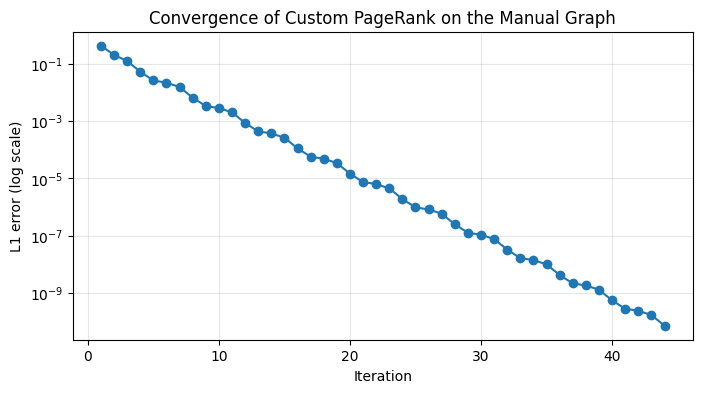

In [83]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(custom_manual["errors"]) + 1), custom_manual["errors"], marker="o")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("L1 error (log scale)")
plt.title("Convergence of Custom PageRank on the Manual Graph")
plt.grid(True, alpha=0.3)
plt.show()

## Validacion contra NetworkX

`NetworkX` se usa como referencia confiable para verificar que la implementacion propia produzca resultados correctos.

Compararemos:
1. los puntajes por nodo,
2. la distancia L1 total,
3. la maxima diferencia absoluta,
4. la correlacion del ranking,
5. el orden final de los nodos.


In [84]:
def pagerank_networkx(
    graph: Dict[str, List[str]],
    d: float = 0.85,
    tol: float = 1e-10,
    max_iter: int = 200
) -> Dict[str, float]:
    """
    Compute PageRank using NetworkX for validation.
    """
    G = graph_to_digraph(graph)
    scores = nx.pagerank(G, alpha=d, tol=tol, max_iter=max_iter)
    return {node: float(scores[node]) for node in sorted(scores.keys())}


def l1_distance(scores1: Dict[str, float], scores2: Dict[str, float]) -> float:
    nodes = sorted(scores1.keys())
    return float(sum(abs(scores1[node] - scores2[node]) for node in nodes))


def max_abs_difference(scores1: Dict[str, float], scores2: Dict[str, float]) -> float:
    nodes = sorted(scores1.keys())
    return float(max(abs(scores1[node] - scores2[node]) for node in nodes))


def spearman_rank_correlation(scores1: Dict[str, float], scores2: Dict[str, float]) -> float:
    s1 = pd.Series(scores1).sort_index()
    s2 = pd.Series(scores2).sort_index()
    ranks1 = s1.rank(method="average", ascending=False)
    ranks2 = s2.rank(method="average", ascending=False)
    return float(ranks1.corr(ranks2, method="pearson"))


def ranking_order(scores: Dict[str, float]) -> List[str]:
    return [node for node, _ in sorted(scores.items(), key=lambda x: (-x[1], x[0]))]


def compare_pagerank_results(custom_scores: Dict[str, float], nx_scores: Dict[str, float]) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    nodes = sorted(custom_scores.keys())

    df = pd.DataFrame({
        "node": nodes,
        "custom": [custom_scores[node] for node in nodes],
        "networkx": [nx_scores[node] for node in nodes]
    })

    df["abs_diff"] = (df["custom"] - df["networkx"]).abs()
    df = df.sort_values("custom", ascending=False).reset_index(drop=True)

    metrics = {
        "l1_distance": l1_distance(custom_scores, nx_scores),
        "max_abs_difference": max_abs_difference(custom_scores, nx_scores),
        "spearman_rank_corr": spearman_rank_correlation(custom_scores, nx_scores),
        "custom_ranking": ranking_order(custom_scores),
        "networkx_ranking": ranking_order(nx_scores),
        "same_ranking_order": ranking_order(custom_scores) == ranking_order(nx_scores)
    }

    return df, metrics

In [49]:
%pip install scipy 

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
nx_manual_scores = pagerank_networkx(
    manual_graph,
    d=0.85,
    tol=1e-10,
    max_iter=200
)

comparison_manual_df, comparison_manual_metrics = compare_pagerank_results(
    custom_manual["scores"],
    nx_manual_scores
)

print("Comparison table:")
display(comparison_manual_df)

print("Metrics:")
for k, v in comparison_manual_metrics.items():
    print(f"{k}: {v}")

Comparison table:


,node,custom,networkx,abs_diff
0,C,0.378476,0.378476,0.000000
1,A,0.369324,0.369324,0.000000
2,B,0.204582,0.204582,0.000000
3,D,0.047619,0.047619,0.000000


Metrics:
l1_distance: 1.2720158260037806e-10
max_abs_difference: 6.360068027788657e-11
spearman_rank_corr: 1.0
custom_ranking: ['C', 'A', 'B', 'D']
networkx_ranking: ['C', 'A', 'B', 'D']
same_ranking_order: True


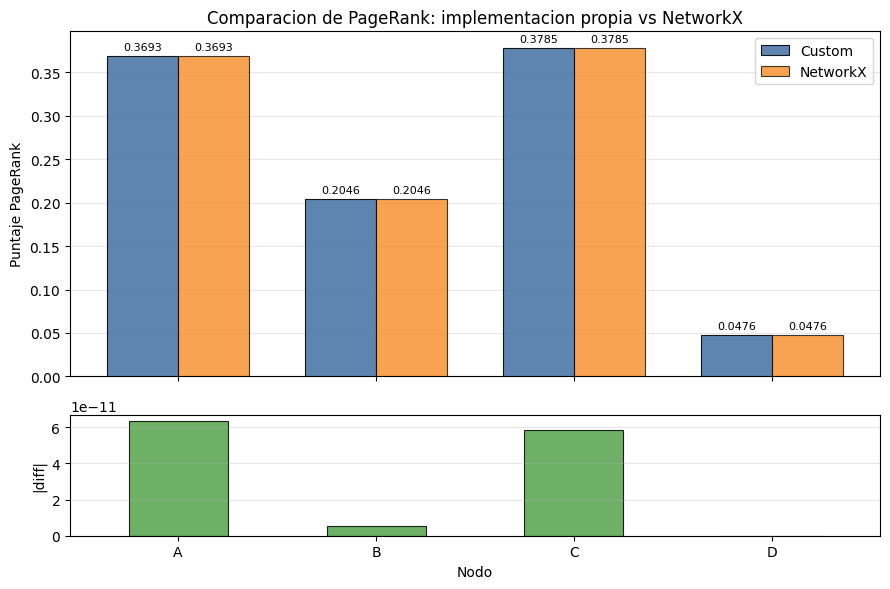

In [86]:
comparison_plot_df = comparison_manual_df.sort_values("node").reset_index(drop=True)

x = np.arange(len(comparison_plot_df))
width = 0.36

fig, (ax_scores, ax_diff) = plt.subplots(
    2,
    1,
    figsize=(9, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1.4]}
)

custom_bars = ax_scores.bar(
    x - width / 2,
    comparison_plot_df["custom"],
    width=width,
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    label="Custom",
    zorder=3
)
networkx_bars = ax_scores.bar(
    x + width / 2,
    comparison_plot_df["networkx"],
    width=width,
    color="#F58518",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.75,
    label="NetworkX",
    zorder=3
)

ax_scores.set_ylabel("Puntaje PageRank")
ax_scores.set_title("Comparacion de PageRank: implementacion propia vs NetworkX")
ax_scores.legend()
ax_scores.grid(True, axis="y", alpha=0.3, zorder=0)
ax_scores.bar_label(custom_bars, fmt="%.4f", padding=3, fontsize=8)
ax_scores.bar_label(networkx_bars, fmt="%.4f", padding=3, fontsize=8)

ax_diff.bar(
    x,
    comparison_plot_df["abs_diff"],
    width=0.5,
    color="#54A24B",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)
ax_diff.set_ylabel("|diff|")
ax_diff.set_xlabel("Nodo")
ax_diff.set_xticks(x)
ax_diff.set_xticklabels(comparison_plot_df["node"])
ax_diff.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax_diff.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


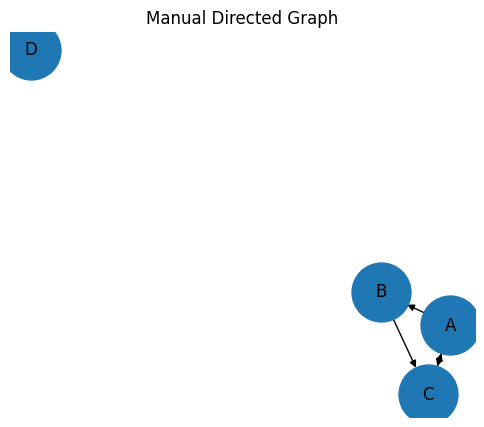

In [87]:
G_manual = graph_to_digraph(manual_graph)
pos = nx.spring_layout(G_manual, seed=RANDOM_SEED)

plt.figure(figsize=(6, 5))
nx.draw_networkx(G_manual, pos=pos, with_labels=True, node_size=1800, font_size=12, arrows=True)
plt.title("Manual Directed Graph")
plt.axis("off")
plt.show()

## Experimento 1: efecto del factor de amortiguamiento

Variamos el factor de amortiguamiento \(d\) y medimos:
- el numero de iteraciones hasta converger,
- el grado de acuerdo con `NetworkX`,
- el nodo mejor posicionado,
- y su puntaje PageRank.


In [88]:
def damping_experiment(
    graph: Dict[str, List[str]],
    damping_values: List[float],
    tol: float = 1e-10,
    max_iter: int = 300
) -> pd.DataFrame:
    rows = []

    for d in damping_values:
        custom_res = pagerank_custom(graph, d=d, tol=tol, max_iter=max_iter, trace=False)
        nx_scores = pagerank_networkx(graph, d=d, tol=tol, max_iter=max_iter)
        _, metrics = compare_pagerank_results(custom_res["scores"], nx_scores)

        top_node = max(custom_res["scores"], key=custom_res["scores"].get)
        top_score = custom_res["scores"][top_node]

        rows.append({
            "damping": d,
            "iterations": custom_res["iterations"],
            "converged": custom_res["converged"],
            "top_node_custom": top_node,
            "top_score_custom": top_score,
            "l1_distance_vs_networkx": metrics["l1_distance"],
            "max_abs_difference_vs_networkx": metrics["max_abs_difference"],
            "spearman_rank_corr": metrics["spearman_rank_corr"],
            "same_ranking_order": metrics["same_ranking_order"]
        })

    return pd.DataFrame(rows).sort_values("damping").reset_index(drop=True)


damping_values = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
damping_results_df = damping_experiment(manual_graph, damping_values)

display(damping_results_df)

,damping,iterations,converged,top_node_custom,top_score_custom,l1_distance_vs_networkx,max_abs_difference_vs_networkx,spearman_rank_corr,same_ranking_order
0,0.700000,32,True,C,0.357560,0.000000,0.000000,1.000000,True
1,0.750000,36,True,C,0.364497,0.000000,0.000000,1.000000,True
2,0.800000,40,True,C,0.371462,0.000000,0.000000,1.000000,True
3,0.850000,44,True,C,0.378476,0.000000,0.000000,1.000000,True
4,0.900000,49,True,C,0.385557,0.000000,0.000000,1.000000,True
5,0.950000,56,True,C,0.392726,0.000000,0.000000,1.000000,True


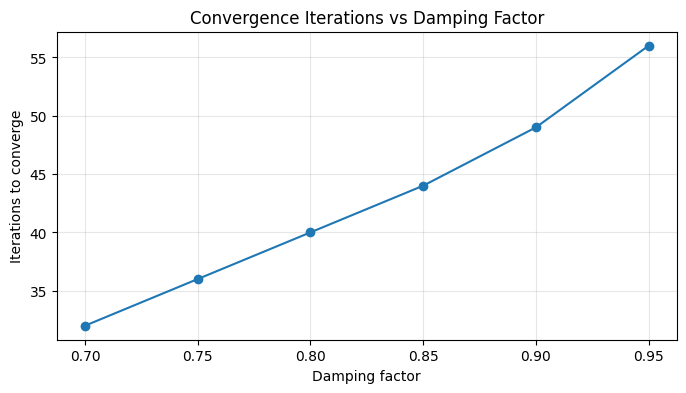

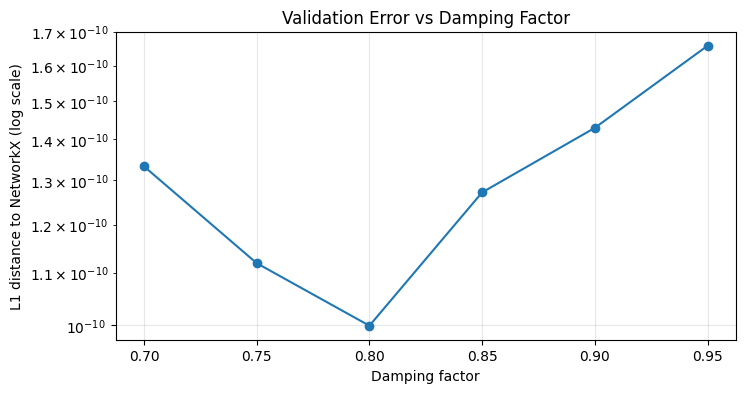

In [89]:
plt.figure(figsize=(8, 4))
plt.plot(damping_results_df["damping"], damping_results_df["iterations"], marker="o")
plt.xlabel("Damping factor")
plt.ylabel("Iterations to converge")
plt.title("Convergence Iterations vs Damping Factor")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(damping_results_df["damping"], damping_results_df["l1_distance_vs_networkx"], marker="o")
plt.yscale("log")
plt.xlabel("Damping factor")
plt.ylabel("L1 distance to NetworkX (log scale)")
plt.title("Validation Error vs Damping Factor")
plt.grid(True, alpha=0.3)
plt.show()

## Experimento 2: tiempo de ejecucion segun el tamano del grafo

Ahora evaluamos como cambia el tiempo de ejecucion cuando aumenta el tamano del grafo en ejemplos sinteticos dirigidos.

Este cuaderno usa una implementacion basada en matrices densas, por lo que el tamano de los grafos se mantiene moderado. Para grafos mucho mas grandes convendria una version con matrices dispersas.


In [90]:
def nx_to_adjacency_dict(G: nx.DiGraph) -> Dict[str, List[str]]:
    """
    Convert a NetworkX DiGraph to our adjacency-dict format.
    """
    graph = {}
    for node in sorted(G.nodes()):
        graph[node] = sorted(list(G.successors(node)))
    return normalize_graph(graph)


def generate_random_directed_graph(n: int, p: float, seed: int) -> Dict[str, List[str]]:
    """
    Generate a random directed graph using NetworkX and convert it
    to our adjacency-dict representation.
    """
    G = nx.gnp_random_graph(n=n, p=p, seed=seed, directed=True)

    # Rename nodes to strings for consistent display and ordering
    mapping = {node: f"N{node}" for node in G.nodes()}
    G = nx.relabel_nodes(G, mapping)

    return nx_to_adjacency_dict(G)

In [91]:
def timing_experiment(
    sizes: List[int],
    repeats: int = 3,
    edge_factor: float = 6.0,
    tol: float = 1e-10,
    max_iter: int = 300,
    damping: float = 0.85
) -> pd.DataFrame:
    """
    For each graph size n, use p = min(edge_factor / n, 0.25)
    to keep average out-degree around edge_factor.
    """
    rows = []

    for n in sizes:
        p = min(edge_factor / n, 0.25)

        for rep in range(repeats):
            seed = RANDOM_SEED + 1000 * n + rep
            graph = generate_random_directed_graph(n=n, p=p, seed=seed)

            start = time.perf_counter()
            custom_res = pagerank_custom(graph, d=damping, tol=tol, max_iter=max_iter, trace=False)
            custom_time = time.perf_counter() - start

            start = time.perf_counter()
            nx_scores = pagerank_networkx(graph, d=damping, tol=tol, max_iter=max_iter)
            nx_time = time.perf_counter() - start

            _, metrics = compare_pagerank_results(custom_res["scores"], nx_scores)

            rows.append({
                "n_nodes": n,
                "edge_probability": p,
                "repeat": rep + 1,
                "n_edges": total_edges(graph),
                "custom_time_sec": custom_time,
                "networkx_time_sec": nx_time,
                "custom_iterations": custom_res["iterations"],
                "converged": custom_res["converged"],
                "l1_distance_vs_networkx": metrics["l1_distance"],
                "max_abs_difference_vs_networkx": metrics["max_abs_difference"],
                "spearman_rank_corr": metrics["spearman_rank_corr"]
            })

    return pd.DataFrame(rows).sort_values(["n_nodes", "repeat"]).reset_index(drop=True)


sizes = [20, 50, 100, 200, 400]
timing_results_raw_df = timing_experiment(sizes=sizes, repeats=3, edge_factor=6.0)

display(timing_results_raw_df.head(10))

,n_nodes,edge_probability,repeat,n_edges,custom_time_sec,networkx_time_sec,custom_iterations,converged,l1_distance_vs_networkx,max_abs_difference_vs_networkx,spearman_rank_corr
0,20,0.250000,1,90,0.001742,0.003860,27,True,0.000000,0.000000,1.000000
1,20,0.250000,2,84,0.000381,0.003587,27,True,0.000000,0.000000,1.000000
2,20,0.250000,3,77,0.000638,0.002001,28,True,0.000000,0.000000,1.000000
3,50,0.120000,1,300,0.000577,0.002994,24,True,0.000000,0.000000,1.000000
4,50,0.120000,2,260,0.000571,0.001814,27,True,0.000000,0.000000,1.000000
5,50,0.120000,3,291,0.000496,0.001717,24,True,0.000000,0.000000,1.000000
6,100,0.060000,1,566,0.001463,0.006111,26,True,0.000000,0.000000,1.000000
7,100,0.060000,2,594,0.000917,0.004776,24,True,0.000000,0.000000,1.000000
8,100,0.060000,3,601,0.000788,0.003466,22,True,0.000000,0.000000,1.000000
9,200,0.030000,1,1156,0.001645,0.004460,24,True,0.000000,0.000000,1.000000


In [92]:
timing_results_summary_df = (
    timing_results_raw_df
    .groupby("n_nodes", as_index=False)
    .agg({
        "n_edges": "mean",
        "custom_time_sec": "mean",
        "networkx_time_sec": "mean",
        "custom_iterations": "mean",
        "l1_distance_vs_networkx": "mean",
        "max_abs_difference_vs_networkx": "mean",
        "spearman_rank_corr": "mean"
    })
)

display(timing_results_summary_df)

,n_nodes,n_edges,custom_time_sec,networkx_time_sec,custom_iterations,l1_distance_vs_networkx,max_abs_difference_vs_networkx,spearman_rank_corr
0,20,83.666667,0.000920,0.003149,27.333333,0.000000,0.000000,1.000000
1,50,283.666667,0.000548,0.002175,25.000000,0.000000,0.000000,1.000000
2,100,587.000000,0.001056,0.004784,24.000000,0.000000,0.000000,1.000000
3,200,1182.000000,0.001605,0.003920,23.666667,0.000000,0.000000,1.000000
4,400,2353.000000,0.004651,0.006923,25.000000,0.000000,0.000000,1.000000


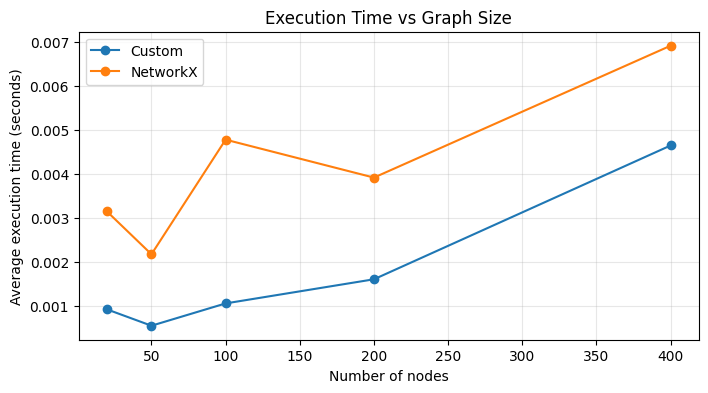

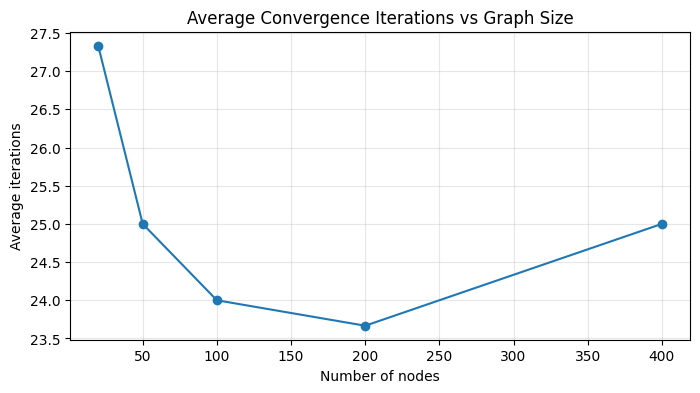

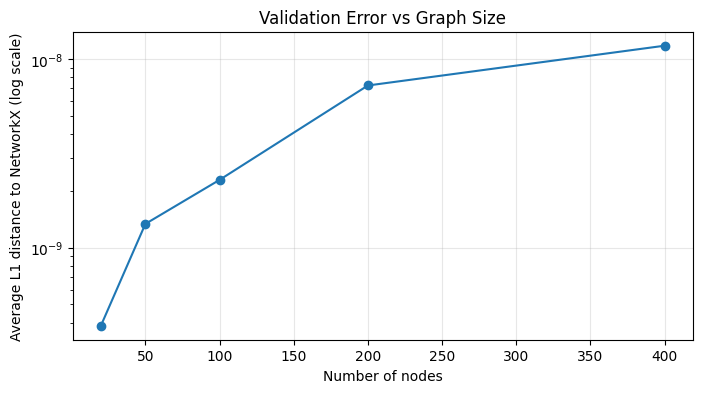

In [93]:
plt.figure(figsize=(8, 4))
plt.plot(timing_results_summary_df["n_nodes"], timing_results_summary_df["custom_time_sec"], marker="o", label="Custom")
plt.plot(timing_results_summary_df["n_nodes"], timing_results_summary_df["networkx_time_sec"], marker="o", label="NetworkX")
plt.xlabel("Number of nodes")
plt.ylabel("Average execution time (seconds)")
plt.title("Execution Time vs Graph Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(timing_results_summary_df["n_nodes"], timing_results_summary_df["custom_iterations"], marker="o")
plt.xlabel("Number of nodes")
plt.ylabel("Average iterations")
plt.title("Average Convergence Iterations vs Graph Size")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(timing_results_summary_df["n_nodes"], timing_results_summary_df["l1_distance_vs_networkx"], marker="o")
plt.yscale("log")
plt.xlabel("Number of nodes")
plt.ylabel("Average L1 distance to NetworkX (log scale)")
plt.title("Validation Error vs Graph Size")
plt.grid(True, alpha=0.3)
plt.show()

## Experimento 3: sensibilidad a cambios estructurales

En esta parte estudiamos como cambia PageRank cuando la estructura del grafo se modifica ligeramente.

La idea es:
1. crear un grafo base,
2. agregar una arista dirigida,
3. eliminar una arista dirigida,
4. comparar los rankings resultantes con el grafo original.


In [94]:
def graph_edges(graph: Dict[str, List[str]]) -> List[Tuple[str, str]]:
    graph = normalize_graph(graph)
    edges = []
    for source, targets in graph.items():
        for target in targets:
            edges.append((source, target))
    return sorted(edges)


def copy_graph(graph: Dict[str, List[str]]) -> Dict[str, List[str]]:
    graph = normalize_graph(graph)
    return {node: list(targets) for node, targets in graph.items()}


def add_edge(graph: Dict[str, List[str]], source: str, target: str) -> Dict[str, List[str]]:
    new_graph = copy_graph(graph)
    if target not in new_graph[source]:
        new_graph[source].append(target)
        new_graph[source] = sorted(new_graph[source])
    return normalize_graph(new_graph)


def remove_edge(graph: Dict[str, List[str]], source: str, target: str) -> Dict[str, List[str]]:
    new_graph = copy_graph(graph)
    if target in new_graph[source]:
        new_graph[source].remove(target)
    return normalize_graph(new_graph)


def top_k_nodes(scores: Dict[str, float], k: int = 5) -> List[str]:
    return [node for node, _ in sorted(scores.items(), key=lambda x: (-x[1], x[0]))[:k]]


def top_k_overlap(scores1: Dict[str, float], scores2: Dict[str, float], k: int = 5) -> int:
    set1 = set(top_k_nodes(scores1, k=k))
    set2 = set(top_k_nodes(scores2, k=k))
    return len(set1.intersection(set2))


def choose_add_and_remove_operations(graph: Dict[str, List[str]], seed: int = RANDOM_SEED) -> Tuple[Tuple[str, str], Tuple[str, str]]:
    """
    Choose one non-edge to add and one existing edge to remove.
    Avoid self-loops for the add operation.
    """
    rng = random.Random(seed)
    graph = normalize_graph(graph)
    nodes = get_nodes(graph)

    existing = set(graph_edges(graph))
    removable_edges = sorted(existing)

    all_possible = []
    for u in nodes:
        for v in nodes:
            if u != v and (u, v) not in existing:
                all_possible.append((u, v))

    if not all_possible:
        raise ValueError("No non-edge available to add.")
    if not removable_edges:
        raise ValueError("No edge available to remove.")

    edge_to_add = rng.choice(all_possible)
    edge_to_remove = rng.choice(removable_edges)

    return edge_to_add, edge_to_remove

In [95]:
base_graph = generate_random_directed_graph(n=40, p=0.10, seed=RANDOM_SEED)
edge_to_add, edge_to_remove = choose_add_and_remove_operations(base_graph, seed=RANDOM_SEED)

graph_added = add_edge(base_graph, *edge_to_add)
graph_removed = remove_edge(base_graph, *edge_to_remove)

print("Edge to add:", edge_to_add)
print("Edge to remove:", edge_to_remove)

base_res = pagerank_custom(base_graph, d=0.85, tol=1e-10, max_iter=300, trace=False)
added_res = pagerank_custom(graph_added, d=0.85, tol=1e-10, max_iter=300, trace=False)
removed_res = pagerank_custom(graph_removed, d=0.85, tol=1e-10, max_iter=300, trace=False)

Edge to add: ('N14', 'N34')
Edge to remove: ('N29', 'N2')


In [96]:
sensitivity_df = pd.DataFrame([
    {
        "scenario": "base vs edge-added",
        "l1_distance": l1_distance(base_res["scores"], added_res["scores"]),
        "max_abs_difference": max_abs_difference(base_res["scores"], added_res["scores"]),
        "spearman_rank_corr": spearman_rank_correlation(base_res["scores"], added_res["scores"]),
        "top5_overlap": top_k_overlap(base_res["scores"], added_res["scores"], k=5)
    },
    {
        "scenario": "base vs edge-removed",
        "l1_distance": l1_distance(base_res["scores"], removed_res["scores"]),
        "max_abs_difference": max_abs_difference(base_res["scores"], removed_res["scores"]),
        "spearman_rank_corr": spearman_rank_correlation(base_res["scores"], removed_res["scores"]),
        "top5_overlap": top_k_overlap(base_res["scores"], removed_res["scores"], k=5)
    }
])

display(sensitivity_df)

,scenario,l1_distance,max_abs_difference,spearman_rank_corr,top5_overlap
0,base vs edge-added,0.017485,0.004342,0.996811,5
1,base vs edge-removed,0.008584,0.002166,0.998499,5


In [97]:
base_top10 = pd.DataFrame(sorted(base_res["scores"].items(), key=lambda x: (-x[1], x[0]))[:10], columns=["node", "base_score"])
added_top10 = pd.DataFrame(sorted(added_res["scores"].items(), key=lambda x: (-x[1], x[0]))[:10], columns=["node", "added_score"])
removed_top10 = pd.DataFrame(sorted(removed_res["scores"].items(), key=lambda x: (-x[1], x[0]))[:10], columns=["node", "removed_score"])

print("Top 10 nodes in the base graph:")
display(base_top10)

print("Top 10 nodes after adding one edge:")
display(added_top10)

print("Top 10 nodes after removing one edge:")
display(removed_top10)

Top 10 nodes in the base graph:


,node,base_score
0,N20,0.056092
1,N6,0.053272
2,N0,0.042560
3,N27,0.040719
4,N38,0.039477
5,N35,0.038777
6,N22,0.032494
7,N36,0.031658
8,N2,0.031541
9,N23,0.030884


Top 10 nodes after adding one edge:


,node,added_score
0,N20,0.055914
1,N6,0.052602
2,N0,0.041406
3,N27,0.040511
4,N38,0.039437
5,N35,0.038870
6,N22,0.032701
7,N34,0.032243
8,N36,0.031630
9,N2,0.031617


Top 10 nodes after removing one edge:


,node,removed_score
0,N20,0.056653
1,N6,0.052944
2,N0,0.042479
3,N27,0.040685
4,N38,0.039495
5,N35,0.038393
6,N22,0.032830
7,N36,0.031852
8,N25,0.031529
9,N23,0.031249


## Exportacion opcional de resultados

Esta celda guarda los resultados de los experimentos en archivos CSV para reutilizarlos despues en el informe, en tablas o en figuras finales.


In [98]:
results_dir = Path("pagerank_results")
results_dir.mkdir(exist_ok=True)

comparison_manual_df.to_csv(results_dir / "manual_comparison.csv", index=False)
damping_results_df.to_csv(results_dir / "damping_experiment.csv", index=False)
timing_results_raw_df.to_csv(results_dir / "timing_experiment_raw.csv", index=False)
timing_results_summary_df.to_csv(results_dir / "timing_experiment_summary.csv", index=False)
sensitivity_df.to_csv(results_dir / "sensitivity_experiment.csv", index=False)

print(f"Results saved in: {results_dir.resolve()}")

Results saved in: C:\Users\User\Desktop\Algoritmos\pagerank_results


## Cierre

Este cuaderno deja una base reproducible para:
- una implementacion completa de PageRank desde cero,
- el manejo correcto de nodos colgantes,
- el analisis de convergencia,
- la validacion contra `NetworkX`,
- los experimentos con damping,
- el estudio de tiempos de ejecucion,
- y la sensibilidad ante cambios estructurales.

Con esto ya tienes una base solida para el informe, la presentacion y futuras mejoras de la implementacion.


In [99]:
print("=== FINAL SUMMARY ===")
print()
print("Manual graph:")
print(f"- Custom implementation converged: {custom_manual['converged']}")
print(f"- Iterations used: {custom_manual['iterations']}")
print(f"- L1 distance vs NetworkX: {comparison_manual_metrics['l1_distance']:.6e}")
print(f"- Same ranking order as NetworkX: {comparison_manual_metrics['same_ranking_order']}")
print()

best_damping_row = damping_results_df.sort_values("l1_distance_vs_networkx").iloc[0]
print("Best damping value in validation experiment:")
print(best_damping_row)
print()

print("Timing experiment summary:")
display(timing_results_summary_df)

print("Sensitivity experiment summary:")
display(sensitivity_df)

=== FINAL SUMMARY ===

Manual graph:
- Custom implementation converged: True
- Iterations used: 44
- L1 distance vs NetworkX: 1.272016e-10
- Same ranking order as NetworkX: True

Best damping value in validation experiment:
damping                          0.800000
iterations                             40
converged                            True
top_node_custom                         C
top_score_custom                 0.371462
l1_distance_vs_networkx          0.000000
max_abs_difference_vs_networkx   0.000000
spearman_rank_corr               1.000000
same_ranking_order                   True
Name: 2, dtype: object

Timing experiment summary:


,n_nodes,n_edges,custom_time_sec,networkx_time_sec,custom_iterations,l1_distance_vs_networkx,max_abs_difference_vs_networkx,spearman_rank_corr
0,20,83.666667,0.000920,0.003149,27.333333,0.000000,0.000000,1.000000
1,50,283.666667,0.000548,0.002175,25.000000,0.000000,0.000000,1.000000
2,100,587.000000,0.001056,0.004784,24.000000,0.000000,0.000000,1.000000
3,200,1182.000000,0.001605,0.003920,23.666667,0.000000,0.000000,1.000000
4,400,2353.000000,0.004651,0.006923,25.000000,0.000000,0.000000,1.000000


Sensitivity experiment summary:


,scenario,l1_distance,max_abs_difference,spearman_rank_corr,top5_overlap
0,base vs edge-added,0.017485,0.004342,0.996811,5
1,base vs edge-removed,0.008584,0.002166,0.998499,5
